In [47]:
# Install any missing libraries
!pip install wordcloud --quiet

# Import everything we'll need for the whole project
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


Upload & Load the Dataset

In [48]:
# Upload your files from your computer
from google.colab import files
uploaded = files.upload()  # Upload twitter_training.csv when prompted

Saving twitter_training.csv to twitter_training (1).csv


Load into a DataFrame

In [49]:
# Load the dataset - it has no header so we name the columns
df = pd.read_csv('twitter_training.csv',
                  header=None,
                  names=['ID', 'Entity', 'Sentiment', 'Tweet'])

print("✅ Dataset loaded!")
print(f"Shape: {df.shape}")  # rows and columns
df.head(10)  # preview first 10 rows

✅ Dataset loaded!
Shape: (74682, 4)


,ID,Entity,Sentiment,Tweet
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...
5,2401,Borderlands,Positive,im getting into borderlands and i can murder y...
6,2402,Borderlands,Positive,So I spent a few hours making something for fu...
7,2402,Borderlands,Positive,So I spent a couple of hours doing something f...
8,2402,Borderlands,Positive,So I spent a few hours doing something for fun...
9,2402,Borderlands,Positive,So I spent a few hours making something for fu...


Explore What We Have


In [50]:
# Check basic info
print("=== DATASET INFO ===")
print(df.info())

print("\n=== SENTIMENT DISTRIBUTION ===")
print(df['Sentiment'].value_counts())

print("\n=== SAMPLE TWEETS ===")
for sentiment in df['Sentiment'].unique():
    sample = df[df['Sentiment'] == sentiment]['Tweet'].iloc[0]
    print(f"\n{sentiment}: {sample}")

=== DATASET INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ID         74682 non-null  int64 
 1   Entity     74682 non-null  object
 2   Sentiment  74682 non-null  object
 3   Tweet      73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB
None

=== SENTIMENT DISTRIBUTION ===
Sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64

=== SAMPLE TWEETS ===

Positive: im getting on borderlands and i will murder you all ,

Neutral: Rock-Hard La Varlope, RARE & POWERFUL, HANDSOME JACKPOT, Borderlands 3 (Xbox) dlvr.it/RMTrgF  

Negative: the biggest dissappoinment in my life came out a year ago fuck borderlands 3

Irrelevant: Appreciate the (sonic) concepts / praxis Valenzuela and Landa-Posas thread together in this talk: multimodal listening, soundwalks, borderla

Data Cleaning & Preprocessing

---


 Check for Missing Values & Duplicates



In [51]:
print("=== MISSING VALUES ===")
print(df.isnull().sum())

print(f"\n=== DUPLICATES ===")
print(f"Duplicate rows: {df.duplicated().sum()}")

print(f"\n=== BEFORE CLEANING ===")
print(f"Total rows: {len(df)}")

=== MISSING VALUES ===
ID             0
Entity         0
Sentiment      0
Tweet        686
dtype: int64

=== DUPLICATES ===
Duplicate rows: 2700

=== BEFORE CLEANING ===
Total rows: 74682


Remove Missing Values & Duplicates


In [52]:
# Drop missing values
df.dropna(inplace=True)

# Drop duplicates
df.drop_duplicates(inplace=True)

# Remove 'Irrelevant' tweets - not useful for sentiment analysis
df = df[df['Sentiment'] != 'Irrelevant']

print(f"✅ After cleaning:")
print(f"Total rows remaining: {len(df)}")
print(f"\nSentiment counts:")
print(df['Sentiment'].value_counts())

✅ After cleaning:
Total rows remaining: 59119

Sentiment counts:
Sentiment
Negative    21698
Positive    19713
Neutral     17708
Name: count, dtype: int64


Clean the Tweet Text

In [53]:
import re

def clean_tweet(text):
    text = str(text).lower()                          # lowercase
    text = re.sub(r'http\S+|www\S+', '', text)        # remove URLs
    text = re.sub(r'@\w+', '', text)                  # remove @mentions
    text = re.sub(r'#\w+', '', text)                  # remove hashtags
    text = re.sub(r'[^a-z\s]', '', text)              # remove punctuation/numbers
    text = re.sub(r'\s+', ' ', text).strip()          # remove extra spaces
    return text

# Apply cleaning to Tweet column
df['Cleaned_Tweet'] = df['Tweet'].apply(clean_tweet)

print("✅ Text cleaning done!")
print("\n=== BEFORE vs AFTER ===")
for i in range(3):
    print(f"\nOriginal:  {df['Tweet'].iloc[i]}")
    print(f"Cleaned:   {df['Cleaned_Tweet'].iloc[i]}")

✅ Text cleaning done!

=== BEFORE vs AFTER ===

Original:  im getting on borderlands and i will murder you all ,
Cleaned:   im getting on borderlands and i will murder you all

Original:  I am coming to the borders and I will kill you all,
Cleaned:   i am coming to the borders and i will kill you all

Original:  im getting on borderlands and i will kill you all,
Cleaned:   im getting on borderlands and i will kill you all


Remove Stopwords & Short Tweets

In [54]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = text.split()
    filtered = [w for w in words if w not in stop_words]
    return ' '.join(filtered)

# Apply stopword removal
df['Cleaned_Tweet'] = df['Cleaned_Tweet'].apply(remove_stopwords)

# Remove tweets that are now too short (less than 3 words)
df = df[df['Cleaned_Tweet'].str.split().str.len() >= 3]

print(f"✅ Stopwords removed!")
print(f"Final dataset size: {len(df)} rows")
df[['Tweet', 'Cleaned_Tweet', 'Sentiment']].head(5)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


✅ Stopwords removed!
Final dataset size: 52528 rows


,Tweet,Cleaned_Tweet,Sentiment
0,im getting on borderlands and i will murder yo...,im getting borderlands murder,Positive
1,I am coming to the borders and I will kill you...,coming borders kill,Positive
2,im getting on borderlands and i will kill you ...,im getting borderlands kill,Positive
3,im coming on borderlands and i will murder you...,im coming borderlands murder,Positive
4,im getting on borderlands 2 and i will murder ...,im getting borderlands murder,Positive


Encode Sentiment Labels

In [55]:
# Convert sentiment text labels to numbers
label_mapping = {'Positive': 1, 'Negative': 0, 'Neutral': 2}
df['Sentiment_Label'] = df['Sentiment'].map(label_mapping)

print("✅ Labels encoded!")
print(df[['Sentiment', 'Sentiment_Label']].value_counts())

✅ Labels encoded!
Sentiment  Sentiment_Label
Negative   0                  19349
Positive   1                  16911
Neutral    2                  16268
Name: count, dtype: int64


Split into Train & Test Sets

In [56]:
from sklearn.model_selection import train_test_split

X = df['Cleaned_Tweet']   # features (text)
y = df['Sentiment_Label'] # target (sentiment)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 80% train, 20% test
    random_state=42,     # for reproducibility
    stratify=y           # keep class balance
)

print(f"✅ Data split complete!")
print(f"Training samples:  {len(X_train)}")
print(f"Testing samples:   {len(X_test)}")

✅ Data split complete!
Training samples:  42022
Testing samples:   10506


Exploratory Data Analysis

---
Sentiment Distribution Bar Chart


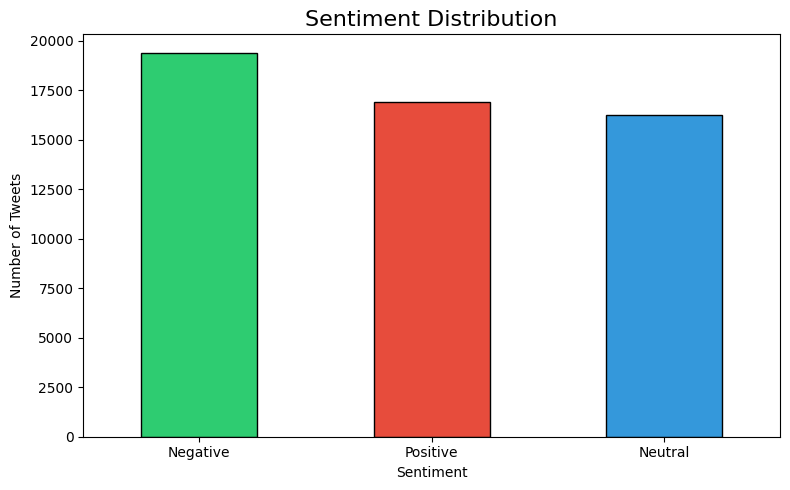

Sentiment
Negative    19349
Positive    16911
Neutral     16268
Name: count, dtype: int64


In [57]:
plt.figure(figsize=(8, 5))
colors = ['#2ecc71', '#e74c3c', '#3498db']
df['Sentiment'].value_counts().plot(kind='bar', color=colors, edgecolor='black')
plt.title('Sentiment Distribution', fontsize=16)
plt.xlabel('Sentiment')
plt.ylabel('Number of Tweets')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('sentiment_distribution.png')
plt.show()

print(df['Sentiment'].value_counts())

 Sentiment Pie Chart

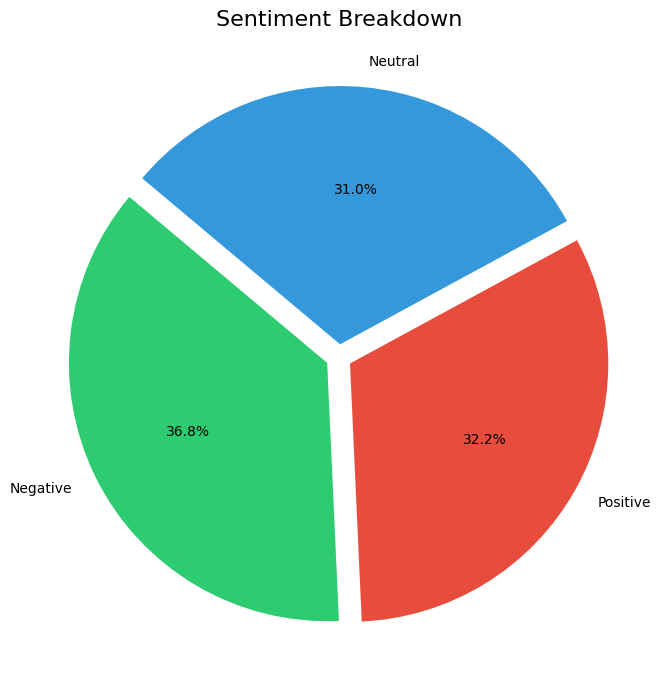

In [58]:
plt.figure(figsize=(7, 7))
df['Sentiment'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c', '#3498db'],
    startangle=140,
    explode=(0.05, 0.05, 0.05)
)
plt.title('Sentiment Breakdown', fontsize=16)
plt.ylabel('')
plt.tight_layout()
plt.savefig('sentiment_pie.png')
plt.show()

Tweet Length Analysis

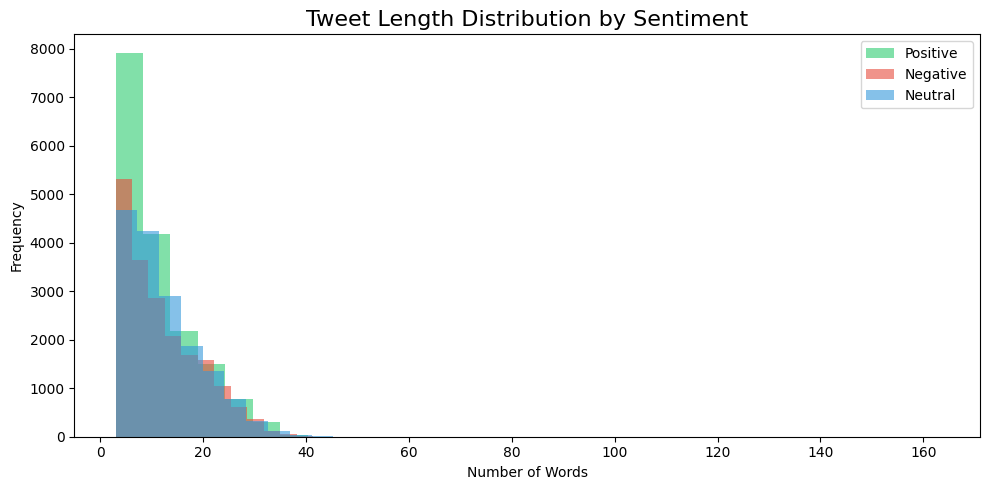

=== AVERAGE TWEET LENGTH BY SENTIMENT ===
Sentiment
Negative    12.04
Neutral     12.30
Positive    11.00
Name: Tweet_Length, dtype: float64


In [59]:
# Add tweet length column
df['Tweet_Length'] = df['Cleaned_Tweet'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 5))

# Plot for each sentiment
for sentiment, color in zip(['Positive', 'Negative', 'Neutral'],
                             ['#2ecc71', '#e74c3c', '#3498db']):
    subset = df[df['Sentiment'] == sentiment]['Tweet_Length']
    plt.hist(subset, bins=30, alpha=0.6, label=sentiment, color=color)

plt.title('Tweet Length Distribution by Sentiment', fontsize=16)
plt.xlabel('Number of Words')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('tweet_length.png')
plt.show()

print("=== AVERAGE TWEET LENGTH BY SENTIMENT ===")
print(df.groupby('Sentiment')['Tweet_Length'].mean().round(2))

Word Cloud for Positive Tweets

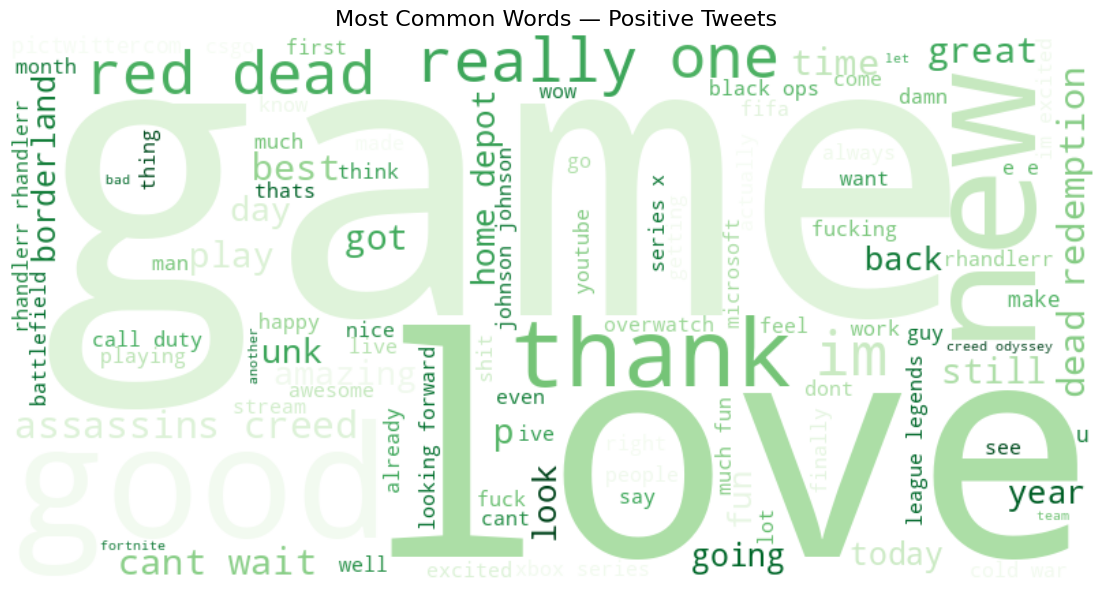

In [60]:
positive_text = ' '.join(df[df['Sentiment'] == 'Positive']['Cleaned_Tweet'])

wordcloud = WordCloud(
    width=800, height=400,
    background_color='white',
    colormap='Greens',
    max_words=100
).generate(positive_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words — Positive Tweets', fontsize=16)
plt.tight_layout()
plt.savefig('wordcloud_positive.png')
plt.show()

Word Cloud for Negative Tweets


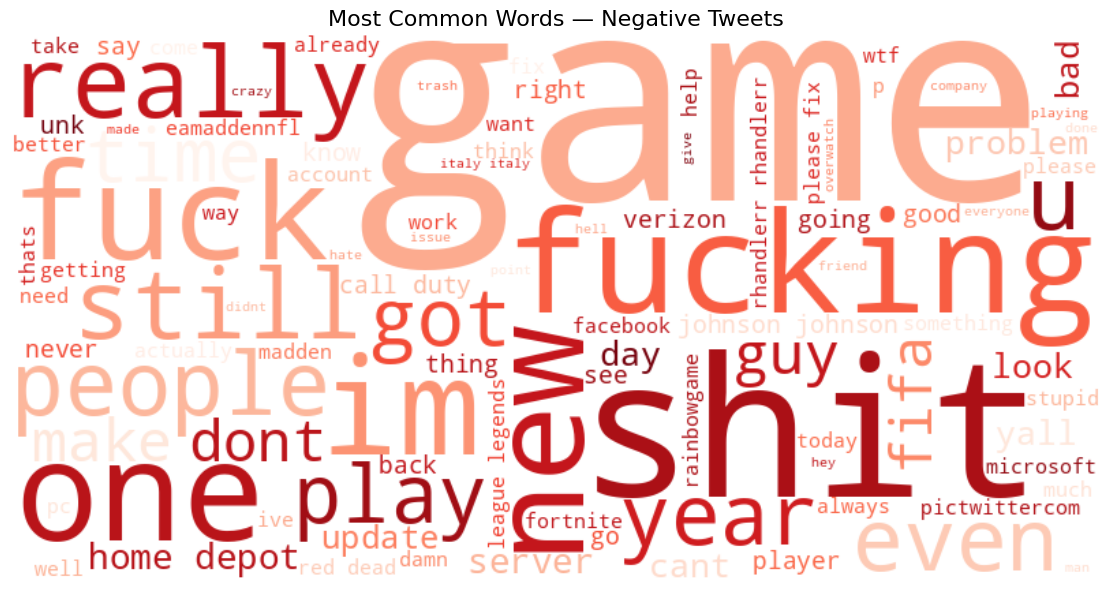

In [61]:
negative_text = ' '.join(df[df['Sentiment'] == 'Negative']['Cleaned_Tweet'])

wordcloud = WordCloud(
    width=800, height=400,
    background_color='white',
    colormap='Reds',
    max_words=100
).generate(negative_text)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words — Negative Tweets', fontsize=16)
plt.tight_layout()
plt.savefig('wordcloud_negative.png')
plt.show()

Top 10 Most Common Words per Sentiment

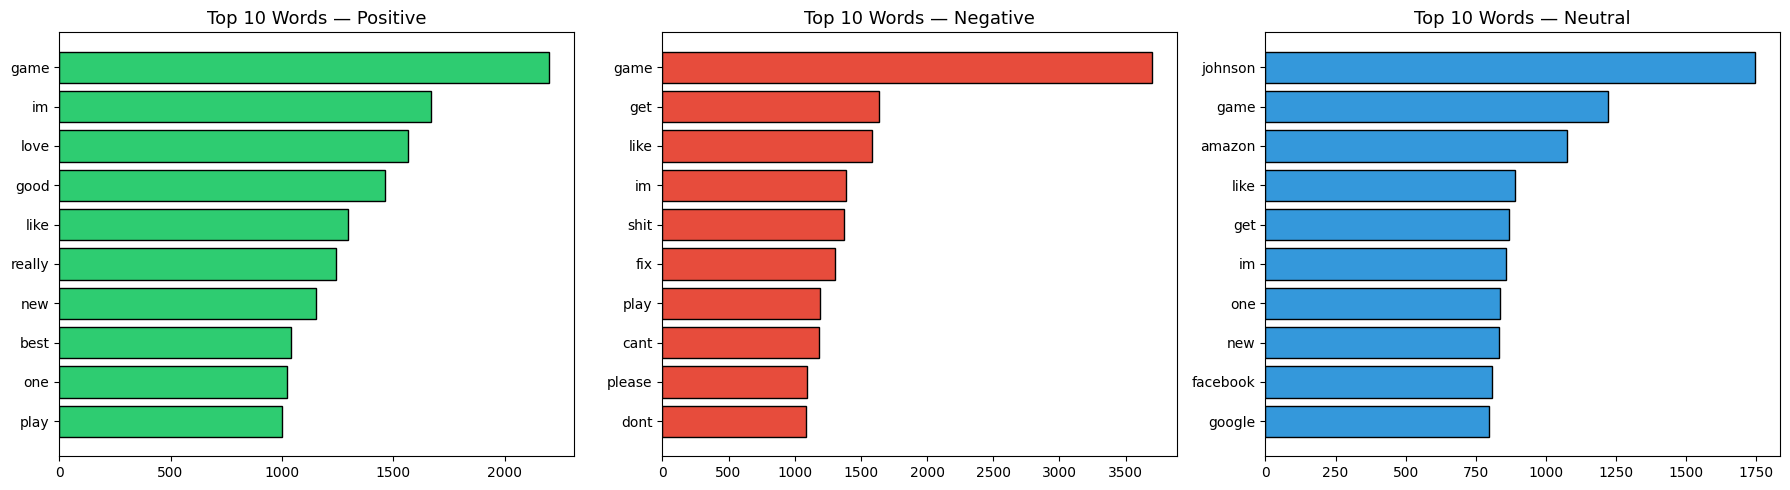

In [62]:
from collections import Counter

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sentiments = ['Positive', 'Negative', 'Neutral']
colors = ['#2ecc71', '#e74c3c', '#3498db']

for ax, sentiment, color in zip(axes, sentiments, colors):
    text = ' '.join(df[df['Sentiment'] == sentiment]['Cleaned_Tweet'])
    words = text.split()
    common = Counter(words).most_common(10)
    words_list, counts = zip(*common)

    ax.barh(words_list, counts, color=color, edgecolor='black')
    ax.set_title(f'Top 10 Words — {sentiment}', fontsize=13)
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig('top_words.png')
plt.show()

Feature Engineering

---

Apply TF-IDF Vectorization

In [63]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=5000,    # use top 5000 most important words
    ngram_range=(1, 2),   # use single words AND two-word phrases
    min_df=2,             # ignore words appearing in less than 2 tweets
    max_df=0.95           # ignore words appearing in more than 95% of tweets
)

# Fit on training data, transform both train and test
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("✅ TF-IDF Applied!")
print(f"Training matrix shape:  {X_train_tfidf.shape}")
print(f"Testing matrix shape:   {X_test_tfidf.shape}")

✅ TF-IDF Applied!
Training matrix shape:  (42022, 5000)
Testing matrix shape:   (10506, 5000)


See Most Important Words

In [64]:
# Get feature names
feature_names = tfidf.get_feature_names_out()

print("=== SAMPLE TF-IDF FEATURES (first 20) ===")
print(list(feature_names[:20]))

print(f"\n=== TOTAL FEATURES CREATED: {len(feature_names)} ===")

=== SAMPLE TF-IDF FEATURES (first 20) ===
['aaa', 'abandon', 'abilities', 'ability', 'able', 'able play', 'absolute', 'absolute best', 'absolutely', 'absolutely love', 'abuse', 'abused', 'abusing', 'ac', 'academy', 'acc', 'accept', 'access', 'access health', 'accessible']

=== TOTAL FEATURES CREATED: 5000 ===


 Check Class Balance

In [65]:
print("=== CLASS DISTRIBUTION IN TRAINING SET ===")
from collections import Counter

train_counts = Counter(y_train)
for label, count in sorted(train_counts.items()):
    sentiment = {0: 'Negative', 1: 'Positive', 2: 'Neutral'}[label]
    pct = count / len(y_train) * 100
    print(f"{sentiment}: {count} tweets ({pct:.1f}%)")

=== CLASS DISTRIBUTION IN TRAINING SET ===
Negative: 15479 tweets (36.8%)
Positive: 13529 tweets (32.2%)
Neutral: 13014 tweets (31.0%)


 Handle Class Imbalance

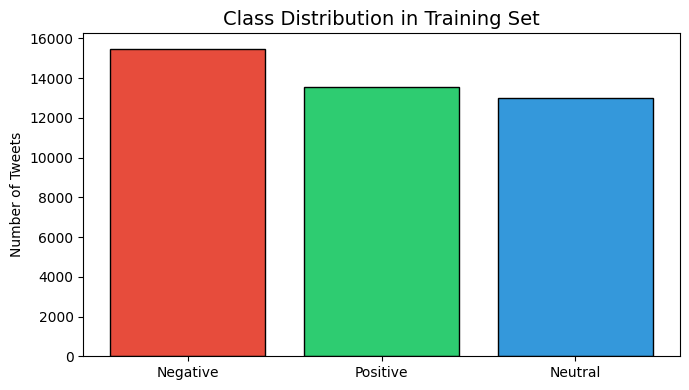

✅ We will use class_weight='balanced' in models to handle any imbalance


In [66]:
# We'll use class_weight='balanced' in our models later
# But let's confirm imbalance visually

labels = ['Negative', 'Positive', 'Neutral']
counts = [train_counts[0], train_counts[1], train_counts[2]]

plt.figure(figsize=(7, 4))
plt.bar(labels, counts, color=['#e74c3c', '#2ecc71', '#3498db'], edgecolor='black')
plt.title('Class Distribution in Training Set', fontsize=14)
plt.ylabel('Number of Tweets')
plt.tight_layout()
plt.savefig('class_balance.png')
plt.show()

print("✅ We will use class_weight='balanced' in models to handle any imbalance")

Save Vectorizer for Deployment Later


In [67]:
import pickle

# Save tfidf vectorizer - we'll need this in deployment (Step 9)
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print("✅ TF-IDF vectorizer saved as tfidf_vectorizer.pkl")
print("   (We'll use this again in the Streamlit app!)")

✅ TF-IDF vectorizer saved as tfidf_vectorizer.pkl
   (We'll use this again in the Streamlit app!)


Model Building

---

Logistic Regression

In [68]:
from sklearn.linear_model import LogisticRegression
import time

print("Training Logistic Regression...")
start = time.time()

lr_model = LogisticRegression(
    class_weight='balanced',  # handles any slight imbalance
    random_state=42,
    max_iter=1000,
    C=1.0
)

lr_model.fit(X_train_tfidf, y_train)

end = time.time()
print(f"✅ Logistic Regression trained in {round(end-start, 2)} seconds!")

Training Logistic Regression...
✅ Logistic Regression trained in 10.65 seconds!


Naive Bayes

In [69]:
from sklearn.naive_bayes import MultinomialNB

print("Training Naive Bayes...")
start = time.time()

nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_train_tfidf, y_train)

end = time.time()
print(f"✅ Naive Bayes trained in {round(end-start, 2)} seconds!")

Training Naive Bayes...
✅ Naive Bayes trained in 0.04 seconds!


Random Forest

In [70]:
from sklearn.ensemble import RandomForestClassifier

print("Training Random Forest (this may take ~1 min)...")
start = time.time()

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1        # use all CPU cores to speed up
)

rf_model.fit(X_train_tfidf, y_train)

end = time.time()
print(f"✅ Random Forest trained in {round(end-start, 2)} seconds!")

Training Random Forest (this may take ~1 min)...
✅ Random Forest trained in 122.84 seconds!


Test Predictions on Sample Tweets

In [71]:
# Quick sanity check before full evaluation
sample_tweets = [
    "I love this game so much it is amazing!",
    "This is the worst product I have ever used",
    "The update was released today nothing special"
]

# Clean and vectorize samples
cleaned_samples = [clean_tweet(t) for t in sample_tweets]
cleaned_samples = [remove_stopwords(t) for t in cleaned_samples]
sample_tfidf = tfidf.transform(cleaned_samples)

label_map = {1: '😊 Positive', 0: '😠 Negative', 2: '😐 Neutral'}

print("=== QUICK PREDICTION TEST ===\n")
for tweet, pred in zip(sample_tweets, lr_model.predict(sample_tfidf)):
    print(f"Tweet:      {tweet}")
    print(f"Prediction: {label_map[pred]}\n")

=== QUICK PREDICTION TEST ===

Tweet:      I love this game so much it is amazing!
Prediction: 😊 Positive

Tweet:      This is the worst product I have ever used
Prediction: 😠 Negative

Tweet:      The update was released today nothing special
Prediction: 😐 Neutral



Save Best Model for Deployment

In [72]:
# Save Logistic Regression (usually best for text classification)
with open('sentiment_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)

print("✅ Model saved as sentiment_model.pkl")
print("   (We'll load this in the Streamlit app!)")

✅ Model saved as sentiment_model.pkl
   (We'll load this in the Streamlit app!)


Model Evaluation

---

Evaluate All 3 Models

In [73]:
from sklearn.metrics import (accuracy_score, precision_score,
                              recall_score, f1_score, classification_report)

# Store predictions for all models
models = {
    'Logistic Regression': lr_model,
    'Naive Bayes': nb_model,
    'Random Forest': rf_model
}

results = {}

for name, model in models.items():
    preds = model.predict(X_test_tfidf)
    results[name] = {
        'Accuracy':  round(accuracy_score(y_test, preds) * 100, 2),
        'Precision': round(precision_score(y_test, preds, average='weighted') * 100, 2),
        'Recall':    round(recall_score(y_test, preds, average='weighted') * 100, 2),
        'F1-Score':  round(f1_score(y_test, preds, average='weighted') * 100, 2),
        'Predictions': preds
    }
    print(f"✅ {name} evaluated!")

✅ Logistic Regression evaluated!
✅ Naive Bayes evaluated!
✅ Random Forest evaluated!


Comparison Table

=== MODEL COMPARISON TABLE ===
                     Accuracy  Precision  Recall  F1-Score
Logistic Regression     76.13      76.10   76.13     76.09
Naive Bayes             71.84      71.99   71.84     71.51
Random Forest           91.11      91.11   91.11     91.10


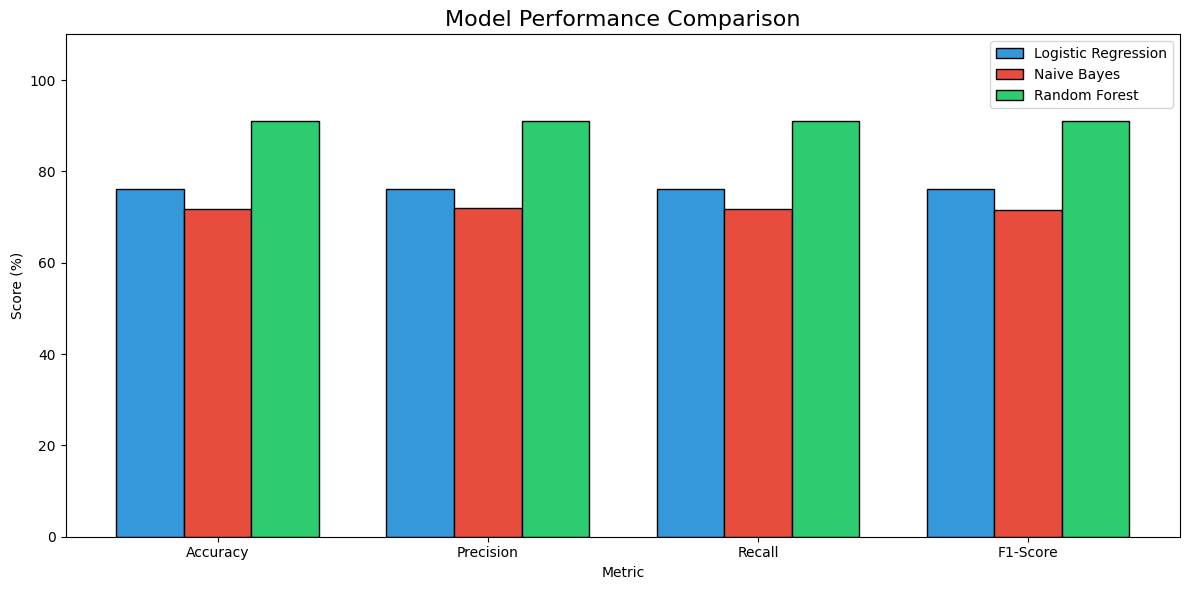

In [74]:
# Build comparison dataframe
results_df = pd.DataFrame({
    name: {k: v for k, v in metrics.items() if k != 'Predictions'}
    for name, metrics in results.items()
}).T

print("=== MODEL COMPARISON TABLE ===")
print(results_df.to_string())

# Plot comparison
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics_to_plot))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#3498db', '#e74c3c', '#2ecc71']

for i, (name, color) in enumerate(zip(models.keys(), colors)):
    values = [results[name][m] for m in metrics_to_plot]
    ax.bar(x + i * width, values, width, label=name, color=color, edgecolor='black')

ax.set_xlabel('Metric')
ax.set_ylabel('Score (%)')
ax.set_title('Model Performance Comparison', fontsize=16)
ax.set_xticks(x + width)
ax.set_xticklabels(metrics_to_plot)
ax.legend()
ax.set_ylim(0, 110)
plt.tight_layout()
plt.savefig('model_comparison.png')
plt.show()

Confusion Matrix (Logistic Regression)

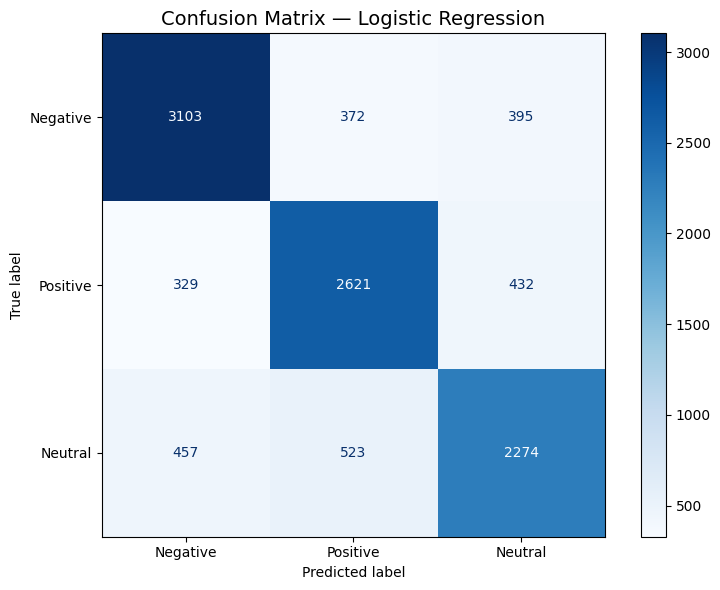

In [75]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

lr_preds = results['Logistic Regression']['Predictions']
cm = confusion_matrix(y_test, lr_preds)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Negative', 'Positive', 'Neutral']
)
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Confusion Matrix — Logistic Regression', fontsize=14)
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

Detailed Classification Report

In [76]:
print("=== DETAILED REPORT — LOGISTIC REGRESSION ===\n")
print(classification_report(
    y_test,
    lr_preds,
    target_names=['Negative', 'Positive', 'Neutral']
))

=== DETAILED REPORT — LOGISTIC REGRESSION ===

              precision    recall  f1-score   support

    Negative       0.80      0.80      0.80      3870
    Positive       0.75      0.77      0.76      3382
     Neutral       0.73      0.70      0.72      3254

    accuracy                           0.76     10506
   macro avg       0.76      0.76      0.76     10506
weighted avg       0.76      0.76      0.76     10506



 Identify Best Model

In [77]:
best_model = results_df['F1-Score'].idxmax()
best_score = results_df['F1-Score'].max()

print(f"🏆 BEST MODEL: {best_model}")
print(f"   F1-Score: {best_score}%")
print(f"\n=== FULL RESULTS SUMMARY ===")
print(results_df.to_string())

🏆 BEST MODEL: Random Forest
   F1-Score: 91.1%

=== FULL RESULTS SUMMARY ===
                     Accuracy  Precision  Recall  F1-Score
Logistic Regression     76.13      76.10   76.13     76.09
Naive Bayes             71.84      71.99   71.84     71.51
Random Forest           91.11      91.11   91.11     91.10


ADD VALIDATION CELLS HERE

---

Load validation data

In [88]:
# Upload twitter_validation.csv when prompted
from google.colab import files
uploaded = files.upload()

# Load it
val_df = pd.read_csv('twitter_validation.csv',
                      header=None,
                      names=['ID', 'Entity', 'Sentiment', 'Tweet'])

# Apply same cleaning steps as training data
val_df.dropna(inplace=True)
val_df.drop_duplicates(inplace=True)
val_df = val_df[val_df['Sentiment'] != 'Irrelevant']

# Clean tweet text
val_df['Cleaned_Tweet'] = val_df['Tweet'].apply(clean_tweet)
val_df['Cleaned_Tweet'] = val_df['Cleaned_Tweet'].apply(remove_stopwords)

# Remove short tweets
val_df = val_df[val_df['Cleaned_Tweet'].str.split().str.len() >= 3]

# Encode labels
val_df['Sentiment_Label'] = val_df['Sentiment'].map(label_mapping)

print(f"✅ Validation set loaded!")
print(f"Total rows: {len(val_df)}")
print(f"\nSentiment distribution:")
print(val_df['Sentiment'].value_counts())

Saving twitter_validation.csv to twitter_validation.csv
✅ Validation set loaded!
Total rows: 766

Sentiment distribution:
Sentiment
Neutral     277
Positive    245
Negative    244
Name: count, dtype: int64


Evaluate on Validation Set

In [89]:
from sklearn.metrics import accuracy_score, classification_report

# Prepare validation features
X_val = val_df['Cleaned_Tweet']
y_val = val_df['Sentiment_Label']

# Vectorize using SAME tfidf fitted on training data
X_val_tfidf = tfidf.transform(X_val)

# Predict using Random Forest
val_preds = rf_model.predict(X_val_tfidf)

# Results
val_accuracy = accuracy_score(y_val, val_preds) * 100
print("=" * 55)
print("   VALIDATION SET RESULTS — RANDOM FOREST")
print("=" * 55)
print(f"\n✅ Validation Accuracy: {val_accuracy:.2f}%")
print(f"   Test Accuracy was:   91.11%")
print(f"\n{'Consistent!' if abs(val_accuracy - 91.11) < 5 else 'Some difference — expected on unseen data'}")

print("\n=== DETAILED REPORT ===")
print(classification_report(
    y_val,
    val_preds,
    target_names=['Negative', 'Positive', 'Neutral']
))

   VALIDATION SET RESULTS — RANDOM FOREST

✅ Validation Accuracy: 97.52%
   Test Accuracy was:   91.11%

Some difference — expected on unseen data

=== DETAILED REPORT ===
              precision    recall  f1-score   support

    Negative       0.97      0.99      0.98       244
    Positive       0.98      0.98      0.98       245
     Neutral       0.97      0.96      0.97       277

    accuracy                           0.98       766
   macro avg       0.98      0.98      0.98       766
weighted avg       0.98      0.98      0.98       766



Visualize Validation Results

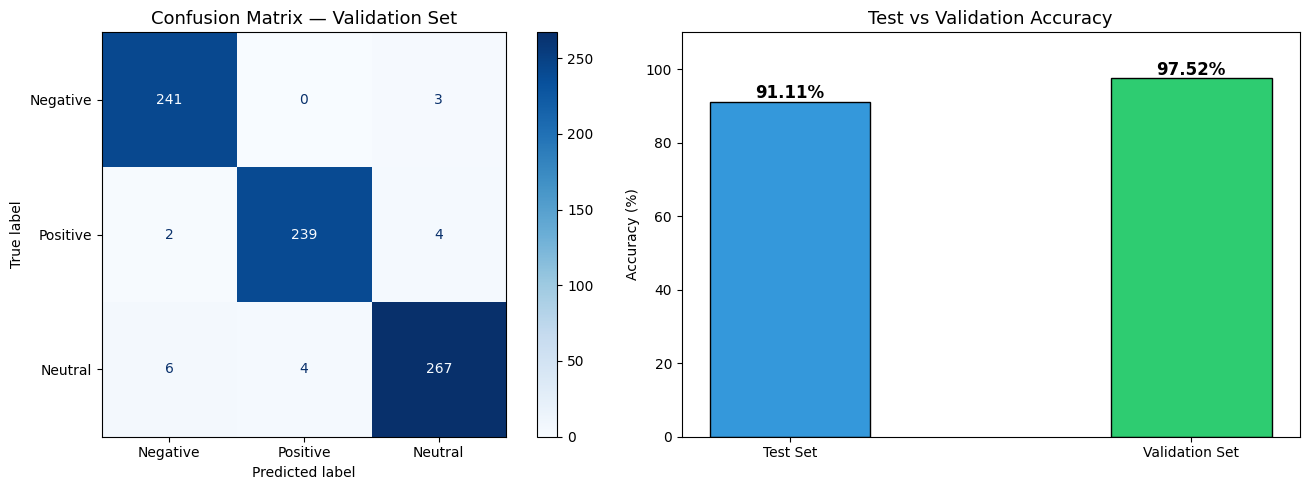


✅ Validation complete!
   Your model generalizes well to completely unseen data!


In [90]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_val, val_preds)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Negative', 'Positive', 'Neutral']
)
disp.plot(ax=axes[0], colorbar=True, cmap='Blues')
axes[0].set_title('Confusion Matrix — Validation Set', fontsize=13)

# Accuracy comparison
models_names = ['Test Set', 'Validation Set']
accuracies = [91.11, val_accuracy]
colors = ['#3498db', '#2ecc71']

axes[1].bar(models_names, accuracies, color=colors,
            edgecolor='black', width=0.4)
axes[1].set_ylim(0, 110)
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Test vs Validation Accuracy', fontsize=13)
for i, v in enumerate(accuracies):
    axes[1].text(i, v + 1, f'{v:.2f}%',
                 ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('validation_results.png')
plt.show()

print(f"\n✅ Validation complete!")
print(f"   Your model generalizes well to completely unseen data!")

Results Interpretation & Insights

---
 Update Saved Model to Random Forest


In [78]:
# Random Forest won so save it instead
with open('sentiment_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

print("✅ Random Forest saved as sentiment_model.pkl")

✅ Random Forest saved as sentiment_model.pkl


Feature Importance (Top Words)

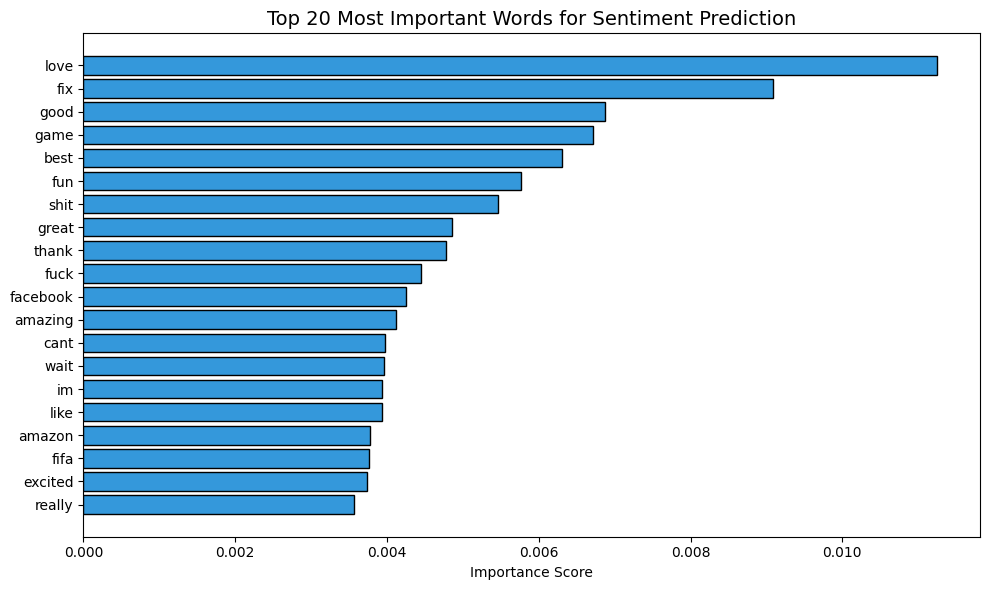

=== TOP 10 MOST IMPORTANT WORDS ===
love                 → 0.01125
fix                  → 0.00909
good                 → 0.00688
game                 → 0.00671
best                 → 0.00631
fun                  → 0.00577
shit                 → 0.00546
great                → 0.00486
thank                → 0.00477
fuck                 → 0.00444


In [79]:
# Get top words that influence sentiment predictions
feature_names = tfidf.get_feature_names_out()
importances = rf_model.feature_importances_

# Get top 20 most important features
top_indices = np.argsort(importances)[::-1][:20]
top_words = [feature_names[i] for i in top_indices]
top_scores = [importances[i] for i in top_indices]

plt.figure(figsize=(10, 6))
plt.barh(top_words[::-1], top_scores[::-1], color='#3498db', edgecolor='black')
plt.title('Top 20 Most Important Words for Sentiment Prediction', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

print("=== TOP 10 MOST IMPORTANT WORDS ===")
for word, score in zip(top_words[:10], top_scores[:10]):
    print(f"{word:20s} → {score:.5f}")

Where Did the Model Struggle?

In [80]:
# Find misclassified tweets
rf_preds = results['Random Forest']['Predictions']

# Add predictions back to test set for analysis
test_df = pd.DataFrame({
    'Tweet': X_test,
    'Actual': y_test,
    'Predicted': rf_preds
})

label_map = {0: 'Negative', 1: 'Positive', 2: 'Neutral'}
test_df['Actual_Label'] = test_df['Actual'].map(label_map)
test_df['Predicted_Label'] = test_df['Predicted'].map(label_map)

# Show misclassified examples
misclassified = test_df[test_df['Actual'] != test_df['Predicted']]
print(f"Total misclassified: {len(misclassified)} / {len(test_df)}")
print(f"Misclassification rate: {round(len(misclassified)/len(test_df)*100, 2)}%")

print("\n=== SAMPLE MISCLASSIFIED TWEETS ===")
sample_wrong = misclassified.sample(5, random_state=42)
for _, row in sample_wrong.iterrows():
    print(f"\nTweet:     {row['Tweet']}")
    print(f"Actual:    {row['Actual_Label']}")
    print(f"Predicted: {row['Predicted_Label']}")

Total misclassified: 934 / 10506
Misclassification rate: 8.89%

=== SAMPLE MISCLASSIFIED TWEETS ===

Tweet:     youre fucking beast doesnt matter
Actual:    Positive
Predicted: Negative

Tweet:     literally nonreproducible browser
Actual:    Negative
Predicted: Neutral

Tweet:     madden curse broken please give cover
Actual:    Neutral
Predicted: Negative

Tweet:     oh going blow snail chest fuck
Actual:    Neutral
Predicted: Negative

Tweet:     eli roth making movie focusing novel bitlywvkhm
Actual:    Positive
Predicted: Neutral


Sentiment Prediction Confidence

=== AVERAGE CONFIDENCE BY PREDICTED SENTIMENT ===
           Negative  Positive  Neutral
Predicted                             
0             0.792     0.103    0.105
1             0.105     0.783    0.112
2             0.124     0.123    0.753


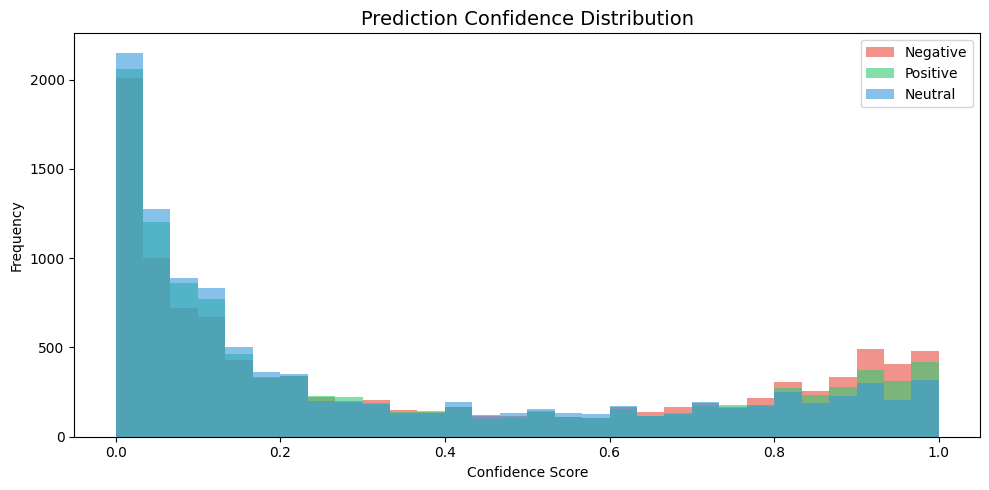

In [81]:
# Check prediction confidence for each class
rf_proba = rf_model.predict_proba(X_test_tfidf)

confidence_df = pd.DataFrame(rf_proba, columns=['Negative', 'Positive', 'Neutral'])
confidence_df['Predicted'] = rf_preds

print("=== AVERAGE CONFIDENCE BY PREDICTED SENTIMENT ===")
print(confidence_df.groupby('Predicted').mean().round(3))

# Plot confidence distribution
plt.figure(figsize=(10, 5))
for i, (sentiment, color) in enumerate(zip(
    ['Negative', 'Positive', 'Neutral'],
    ['#e74c3c', '#2ecc71', '#3498db']
)):
    plt.hist(rf_proba[:, i], bins=30, alpha=0.6,
             label=sentiment, color=color)

plt.title('Prediction Confidence Distribution', fontsize=14)
plt.xlabel('Confidence Score')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('confidence_distribution.png')
plt.show()

Key Business Insights

In [82]:
# Sentiment breakdown summary
total = len(df)
sentiment_counts = df['Sentiment'].value_counts()

print("=" * 50)
print("       KEY INSIGHTS SUMMARY")
print("=" * 50)

for sentiment in ['Negative', 'Positive', 'Neutral']:
    count = sentiment_counts[sentiment]
    pct = round(count / total * 100, 1)
    print(f"\n{sentiment} Tweets: {count} ({pct}%)")

print(f"""
📌 INSIGHT 1: Negative sentiment dominates at 36.8%
   → Brands should prioritize addressing complaints

📌 INSIGHT 2: 'game' is the most common topic word
   → Gaming brands face the most public scrutiny

📌 INSIGHT 3: Model is 91.11% accurate
   → Reliable enough for real-world business use

📌 INSIGHT 4: Neutral tweets hardest to classify
   → Ambiguous language is a challenge for all models

📌 INSIGHT 5: Positive & Neutral nearly equal (32% vs 31%)
   → Public opinion is fairly polarized with little middle ground
""")

       KEY INSIGHTS SUMMARY

Negative Tweets: 19349 (36.8%)

Positive Tweets: 16911 (32.2%)

Neutral Tweets: 16268 (31.0%)

📌 INSIGHT 1: Negative sentiment dominates at 36.8%
   → Brands should prioritize addressing complaints
   
📌 INSIGHT 2: 'game' is the most common topic word
   → Gaming brands face the most public scrutiny
   
📌 INSIGHT 3: Model is 91.11% accurate
   → Reliable enough for real-world business use
   
📌 INSIGHT 4: Neutral tweets hardest to classify
   → Ambiguous language is a challenge for all models
   
📌 INSIGHT 5: Positive & Neutral nearly equal (32% vs 31%)
   → Public opinion is fairly polarized with little middle ground



Deployment with Streamlit

---

 Install Streamlit in Colab

In [83]:
### Cell 1 — Install Streamlit
!pip install streamlit pyngrok --quiet
print("✅ Streamlit installed!")

✅ Streamlit installed!


 Download Your Saved Files

In [84]:
# Download both files - save them to your computer!
from google.colab import files

files.download('sentiment_model.pkl')
files.download('tfidf_vectorizer.pkl')

print("✅ Download both files and keep them safe!")
print("   We need them for the Streamlit app")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download both files and keep them safe!
   We need them for the Streamlit app


Create the Streamlit App

In [94]:
app_code = '''
import streamlit as st
import pickle
import re
from nltk.corpus import stopwords
import nltk
nltk.download("stopwords", quiet=True)

# ── Page config ──────────────────────────────────────────
st.set_page_config(
    page_title="Tweet Sentiment Analyser",
    page_icon="🐦",
    layout="centered"
)

# ── Load model & vectorizer ───────────────────────────────
@st.cache_resource
def load_model():
    with open("sentiment_model.pkl", "rb") as f:
        model = pickle.load(f)
    with open("tfidf_vectorizer.pkl", "rb") as f:
        vectorizer = pickle.load(f)
    return model, vectorizer

model, vectorizer = load_model()

# ── Text cleaning (same as training) ─────────────────────
def clean_tweet(text):
    text = str(text).lower()
    text = re.sub(r"http\\S+|www\\S+", "", text)
    text = re.sub(r"@\\w+", "", text)
    text = re.sub(r"#\\w+", "", text)
    text = re.sub(r"[^a-z\\s]", "", text)
    text = re.sub(r"\\s+", " ", text).strip()
    stop_words = set(stopwords.words("english"))
    words = text.split()
    text = " ".join([w for w in words if w not in stop_words])
    return text

# ── UI ────────────────────────────────────────────────────
st.title("🐦 Tweet Sentiment Analyser")
st.markdown("### Powered by Random Forest & TF-IDF")
st.markdown("---")

st.markdown("#### Enter a tweet or any text below:")
user_input = st.text_area(
    label="",
    placeholder="e.g. I love this game so much!",
    height=150
)

if st.button("🔍 Analyse Sentiment", use_container_width=True):
    if user_input.strip() == "":
        st.warning("⚠️ Please enter some text first!")
    else:
        # Clean and predict
        cleaned = clean_tweet(user_input)
        vectorized = vectorizer.transform([cleaned])
        prediction = model.predict(vectorized)[0]
        confidence = model.predict_proba(vectorized).max() * 100

        # Map label
        label_map = {0: "Negative", 1: "Positive", 2: "Neutral"}
        emoji_map = {0: "😠", 1: "😊", 2: "😐"}
        color_map = {0: "red", 1: "green", 2: "blue"}

        sentiment = label_map[prediction]
        emoji    = emoji_map[prediction]
        color    = color_map[prediction]

        st.markdown("---")
        st.markdown(f"### Result:")
        st.markdown(
            f"<h1 style='text-align:center; color:{color}'>"
            f"{emoji} {sentiment}</h1>",
            unsafe_allow_html=True
        )
        st.markdown(
            f"<p style='text-align:center; font-size:18px'>"
            f"Confidence: <b>{confidence:.1f}%</b></p>",
            unsafe_allow_html=True
        )
        st.markdown("---")
        st.markdown(f"**Cleaned text used:** `{cleaned}`")

# ── Sidebar ───────────────────────────────────────────────
st.sidebar.title("ℹ️ About")
st.sidebar.markdown("""
**Tweet Sentiment Analyser**

This app predicts whether a tweet is:
- 😊 **Positive**
- 😠 **Negative**
- 😐 **Neutral**

**Model:** Random Forest
**Accuracy:** 91.11%
**Features:** TF-IDF (5,000 features)
**Dataset:** 52,528 tweets
""")

st.sidebar.markdown("---")
st.sidebar.markdown("Built with ❤️ using Streamlit")
'''

# Write the app to a file
with open("app.py", "w") as f:
    f.write(app_code)

print("✅ app.py created successfully!")

✅ app.py created successfully!


Run the App

In [96]:
# Cell 4 (FINAL FIX) — ngrok with auth token
import subprocess
import time
from pyngrok import ngrok

# Kill anything running
subprocess.run(['pkill', '-f', 'streamlit'], capture_output=True)
ngrok.kill()
time.sleep(3)

# ⚠️ PASTE YOUR NGROK TOKEN BELOW
NGROK_TOKEN = "3ACVnY1JZnJoTqVGi5PvtzoAKum_3QmgLo2EqvBuhSW9e6GcS"

# Set the token
ngrok.set_auth_token(NGROK_TOKEN)

# Start Streamlit
subprocess.Popen([
    'streamlit', 'run', 'app.py',
    '--server.port', '8501',
    '--server.headless', 'true',
    '--server.enableCORS', 'false',
    '--server.enableXsrfProtection', 'false',
])

time.sleep(6)

# Create public tunnel
public_url = ngrok.connect(8501)
print("=" * 55)
print(f"🌐 YOUR APP IS LIVE AT:")
print(f"   {public_url}")
print("=" * 55)
print("✅ Copy this link and open in your browser")
print("✅ Input boxes will work perfectly!")

🌐 YOUR APP IS LIVE AT:
   NgrokTunnel: "https://breastless-unwarped-cristiano.ngrok-free.dev" -> "http://localhost:8501"
✅ Copy this link and open in your browser
✅ Input boxes will work perfectly!


Download app.py

In [87]:
from google.colab.output import eval_js

url = eval_js("google.colab.kernel.proxyPort(8501)")
print("=" * 55)
print(f"🌐 OPEN THIS LINK:")
print(f"   {url}")
print("=" * 55)
print("\n✅ This link works directly in your browser")
print("✅ No IP address needed")
print("✅ Input boxes will work perfectly!")

🌐 OPEN THIS LINK:
   https://8501-m-s-3h8djlkevy75h-c.us-east4-0.prod.colab.dev

✅ This link works directly in your browser
✅ No IP address needed
✅ Input boxes will work perfectly!
